In [1]:
from IPython.display import Image, display, Markdown
from langchain_core.messages import (
    AIMessage,
    BaseMessage,
    HumanMessage,
    SystemMessage,
    ToolMessage,
)


def print_state(state):
    if not "messages" in state:
        return

    for message in state["messages"]:
        if isinstance(message, SystemMessage):
            print("💻" * 15, "SYSTEM MESSAGE", "💻" * 15)

        elif isinstance(message, AIMessage):
            print("🤖" * 15, "AI MESSAGE", "🤖" * 15)

            if hasattr(message, "tool_calls"):
                print(message.tool_calls)

        elif isinstance(message, HumanMessage):
            print(" " * 40, "👱🏻‍♀️" * 15, "HUMAN MESSAGE", "👱🏻‍♀️" * 15)
            message.content = " " * 30 + message.content

        else:
            print("🔨" * 15, "TOOL MESSAGE", "🔨" * 15)

        print(message.content)
        print("🚀" * 50)
        print("\n\n")

In [2]:
from ml_agent.data_cleaning_agent.agent import DataCleaningAgent, ImputationToolkit
from ml_agent.feature_transform_agent.agent import FeatureEngineeringAgent, FeatureEngineeringToolkit

import pandas as pd

In [3]:
from langchain_groq import ChatGroq
import getpass
import os

os.environ["GROQ_API_KEY"] = getpass.getpass()

LLAMA_8B = "llama3-8b-8192"
LLAMA_70B = "llama3-70b-8192"
GEMMA2_9B = "gemma2-9b-it"

model = ChatGroq(model=LLAMA_8B)

 ········


In [4]:
df = pd.read_csv("./data/healthcare-dataset-stroke-data.csv")
df_state = df.to_dict()
toolkit = ImputationToolkit(df_state=df_state)
imputation_tools = toolkit.get_tools()

#### Data cleaning

In [5]:
llm = model

In [6]:
data_cleaning_agent = DataCleaningAgent(llm=llm, tools=imputation_tools)._create_agent_workflow()

In [14]:
data_cleaning_state = data_cleaning_agent.invoke(input={"question": "Clean the data"})

🔥🔥 Calling Model 🔥🔥 Clean the data
🎯 Model Response:  
🎯 Model Tool Calls: [{'name': 'list_columns', 'args': {}, 'id': 'call_apgc', 'type': 'tool_call'}, {'name': 'missing_value_percent', 'args': {}, 'id': 'call_bsrn', 'type': 'tool_call'}] 
Checking Condition: Should Continue 🤔? 
Decision: Continue ✅(Call Tool) ---
🔥🔥 Calling Tool 🔥🔥
--- Executing Tool: list_columns ---
--- Tool Output: Index(['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'Residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status', 'stroke'],
      dtype='object') ---
--- Executing Tool: missing_value_percent ---
--- Tool Output: {'id': 0.0, 'gender': 0.0, 'age': 0.0, 'hypertension': 0.0, 'heart_disease': 0.0, 'ever_married': 0.0, 'work_type': 0.0, 'Residence_type': 0.0, 'avg_glucose_level': 0.0, 'bmi': 4.0, 'smoking_status': 0.0, 'stroke': 0.0} ---
🔥🔥 Calling Model 🔥🔥 Clean the data
🎯 Model Response:  
🎯 Model Tool Calls: [{'name': 'simple_imputer', 'args': {'co

NameError: name 'print_state' is not defined

In [18]:
print_state(data_cleaning_state)

💻💻💻💻💻💻💻💻💻💻💻💻💻💻💻 SYSTEM MESSAGE 💻💻💻💻💻💻💻💻💻💻💻💻💻💻💻

You are an agent specialized to clean a pandas Dataframe.

You have access to tools for cleaning the dataframe.

Only use the below tools. Only use the information returned by the below tools to clean the data.

To start you should ALWAYS look at the columns in the dataframe.
Do NOT skip this step.

Then, for each of the columns, you should select appropriate tools to clean the column according to data type and distribution of that column.

If there are no missing values in the dataframe, do not use any tool.

🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀



🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖 AI MESSAGE 🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖
[]
I'm ready to clean the pandas Dataframe!

First, I'll take a look at the columns in the dataframe using `df.columns`. This will give me an overview of the columns and their names.

Let's assume the output is:
```
Index(['A', 'B', 'C', 'D', 'E'], dtype='object')
```
Next, I'll iterate through each column and examine its data type and d

#### Feature engineering

In [8]:
llm2 = model

In [30]:
feat_engg_agent = FeatureEngineeringAgent(llm=llm2, tools=FeatureEngineeringToolkit().get_tools())._create_agent_workflow()

In [14]:
# app_2 = feat_agent._create_agent_workflow()

In [46]:
feat_engg_system_prompt = SystemMessage(content="""
You are an expert feature engineering assistant. Your primary goal is to analyze user requests to modify a pandas DataFrame and select the single most appropriate tool from your toolkit to perform the requested transformation.

You operate based on the current state of the DataFrame, a summary of which (columns and data types) will be provided in the conversation history or system context.

**Your Available Tools:**

*   `scale_numerical_features`: Applies Standard (Z-score) or Min-Max scaling to a numerical column. Requires the column name and scaling method ('standard' or 'minmax'). Creates a new column.
*   `one_hot_encode_categorical_feature`: Converts a categorical/object column into multiple binary columns. Requires the column name. Optionally drops the original column. Try not to use unless absolutely necessary as it can increase the dimensionality too much.
*   `label_encode_categorical_feature`: Converts a categorical/object column into numerical labels (0, 1, 2,...). Requires the column name. Replaces the original column.
*   `target_encode_categorical_feature`: Encodes a categorical column based on the mean of a specified numerical target variable. Requires the column to encode, the target column name. Creates a new column, optionally drops the original. (Note: Requires 'category_encoders' library).
*   `convert_to_datetime`: Converts a column (string/object) containing date/time information into datetime objects. Requires the column name. Optionally accepts a specific format string. Replaces the original column.

**Instructions:**

1.  **Analyze Request:** Carefully examine the user's latest request in the context of the provided DataFrame summary (pay close attention to column names and types).
2.  **Select ONE Tool:** Choose the *single* tool from the list above that best matches the user's intent for feature transformation or engineering.
3.  **Determine Parameters:** Identify the correct column(s) and other parameters required by the chosen tool based *only* on the user request and the DataFrame structure. Ensure the parameters are valid (e.g., use existing column names, choose appropriate methods like 'standard'/'minmax', ensure column types are suitable for the operation).
4.  **Invoke Tool:** Structure your response to call the selected tool with the precisely determined parameters.
5.  **Constraint:** You must *only* use the tools provided. Do not invent new operations or attempt to generate raw Python code. Call at most **one** tool per response. If a request requires multiple steps (e.g., impute then scale), address only the first logical step identified in the request with a single tool call.
6.  Do not use a tool on the same column again and again. For example, if you have used `scale_numerical_features` on column X, you should not use it again on X or X_scaled.
7.  Use encoding tools only for non numeric columns.
""")

In [47]:
config = {"recursion_limit": 50}
# df = pd.read_csv("./synthetic_data.csv")
initial_state = {
    "dataframe": df.copy(), # Start fresh for each independent request for clarity
    "original_request": "do feature engineering",
    "messages": [feat_engg_system_prompt] # Messages will be added by the start node
}

# response = app_2.invoke(initial_state, config)

In [18]:
print_state(response)

💻💻💻💻💻💻💻💻💻💻💻💻💻💻💻 SYSTEM MESSAGE 💻💻💻💻💻💻💻💻💻💻💻💻💻💻💻

You are an expert feature engineering assistant. Your primary goal is to analyze user requests to modify a pandas DataFrame and select the single most appropriate tool from your toolkit to perform the requested transformation.

You operate based on the current state of the DataFrame, a summary of which (columns and data types) will be provided in the conversation history or system context.

**Your Available Tools:**

*   `scale_numerical_features`: Applies Standard (Z-score) or Min-Max scaling to a numerical column. Requires the column name and scaling method ('standard' or 'minmax'). Creates a new column.
*   `one_hot_encode_categorical_feature`: Converts a categorical/object column into multiple binary columns. Requires the column name. Optionally drops the original column. Try not to use unless absolutely necessary as it can increase the dimensionality too much.
*   `label_encode_categorical_feature`: Converts a categorical/object colu

### Parent graph agent

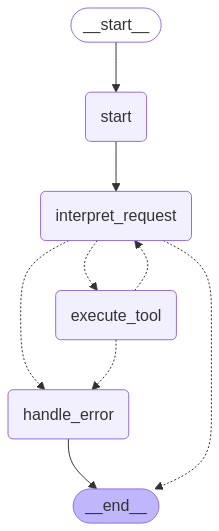

In [31]:
feat_engg_agent

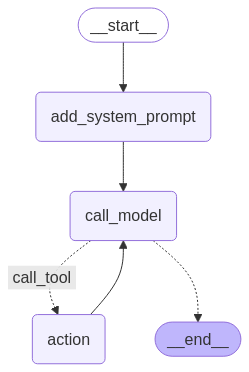

In [28]:
data_cleaning_agent

In [21]:
import os
import operator
from typing import TypedDict, Annotated, List, Optional, Union, Literal

from langgraph.types import Command
from langgraph.graph import MessagesState, StateGraph, END, START

In [38]:
members = ["data_cleaner", "feature_engineer"]
options = members + ["FINISH"]

system_prompt = (
    "You are a supervisor tasked with managing a conversation between the"
    f" following workers: {members}. Given the following user request,"
    " respond with the worker to act next. Each worker will perform a"
    " task and respond with their results and status. When finished,"
    " respond with FINISH."
)

In [39]:
class Router(TypedDict):
    """Worker to route to next. If no workers needed, route to FINISH."""

    next: Literal[*options]


class State(MessagesState):
    next: str


def supervisor_node(state: State) -> Command[Literal[*members, "__end__"]]:
    messages = [
        {"role": "system", "content": system_prompt},
    ] + state["messages"]
    response = llm.with_structured_output(Router).invoke(messages)
    goto = response["next"]

    if goto == "FINISH":
        goto = END

    return Command(goto=goto, update={"next": goto})

In [48]:
def clean_node(state: State) -> Command[Literal["supervisor"]]:
    result = data_cleaning_agent.invoke({"question": "Clean the data"})

    return Command(
        update={
            "messages": [
                HumanMessage(content=result["messages"][-1].content, name="data_cleaner")
            ]
        },
        goto="supervisor",
    )

def feat_node(state: State) -> Command[Literal["supervisor"]]:
    config = {"recursion_limit": 50}

    initial_state = {
        "dataframe": df.copy(),
        "original_request": "do feature engineering",
        "messages": [feat_engg_system_prompt]
    }
    result = feat_engg_agent.invoke(initial_state, config)

    return Command(
        update={
            "messages": [
                HumanMessage(content=result["messages"][-1].content, name="feature_engineer")
            ]
        },
        goto="supervisor",
    )

In [49]:
builder = StateGraph(State)
builder.add_edge(START, "supervisor")
builder.add_node("supervisor", supervisor_node)
builder.add_node("data_cleaner", clean_node)
builder.add_node("feature_engineer", feat_node)
graph = builder.compile()

In [ ]:
graph.invoke({
    "messages": []
})

🔥🔥 Calling Model 🔥🔥 Clean the data
🎯 Model Response:  
🎯 Model Tool Calls: [{'name': 'list_columns', 'args': {}, 'id': 'call_e61f', 'type': 'tool_call'}] 
Checking Condition: Should Continue 🤔? 
Decision: Continue ✅(Call Tool) ---
🔥🔥 Calling Tool 🔥🔥
--- Executing Tool: list_columns ---
--- Tool Output: Index(['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'Residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status', 'stroke'],
      dtype='object') ---
🔥🔥 Calling Model 🔥🔥 Clean the data
🎯 Model Response:  
🎯 Model Tool Calls: [{'name': 'list_columns', 'args': {'columns': ['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'avg_glucose_level', 'bmi', 'smoking_status', 'stroke']}, 'id': 'call_12ka', 'type': 'tool_call'}] 
Checking Condition: Should Continue 🤔? 
Decision: Continue ✅(Call Tool) ---
🔥🔥 Calling Tool 🔥🔥
--- Executing Tool: list_columns ---
--- Tool Output: Index(['id', 'g

In [ ]:
class SupervisorState(TypedDict):
    input: str
    # History of messages or actions
    messages: Annotated[List[Union[str, tuple]], add]

In [ ]:
builder = StateGraph(ParentState)
builder.add_node("node_1", node_1)
# note that we're adding the compiled subgraph as a node to the parent graph
builder.add_node("node_2", subgraph)
builder.add_edge(START, "node_1")
builder.add_edge("node_1", "node_2")
graph = builder.compile()